In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-yaml-file/data.yaml
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/README.dataset.txt
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/README.roboflow.txt
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/data.yaml
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/valid/labels/IMG_0560_PNG.rf.101e922bccb9851e071441ddda53d610.txt
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/valid/labels/2Q__-1-_face_png.rf.7796ee83d64306852cf7f948f3b84d70.txt
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/valid/labels/IMG_1542_PNG.rf.771eb7c15f2f46c7d13df69c84a3a14b.txt
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/valid/labels/sad_jpeg.rf.0289490f8d77c8329964367ed617a1f9.txt
/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/valid/labels/IMG_0912_PNG.rf.c0eba89fc928da07f09b3c310a76a6e7.txt
/kaggle/input/emotion-recognit

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:0000:01


In [3]:
# import libraries
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import pandas as pd
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Explore the dataset
yaml_path = '/kaggle/input/data-yaml-file/data.yaml'
with open(yaml_path, 'r') as file:
    data_yaml = yaml.safe_load(file)

print("Class names:", data_yaml['names'])
print("Number of classes:", data_yaml['nc'])

Class names: ['angry', 'happy', 'sad', 'surprised']
Number of classes: 4


In [ ]:
# Train the YOLOv9 Model
model = YOLO('yolov9s.pt')  # or even 'yolov8m.pt' if resources allow
#pretrained model given by YOLO library
model.train(
    data='/kaggle/input/data-yaml-file/data.yaml',
    epochs=40,  
    imgsz=640,
    batch=16,
    name='Emotion Recobnition',
    project='/kaggle/working',
    val=True,
    augment=True,  
    mosaic=1.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.2,
    fliplr=0.5
)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/data-yaml-file/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Emotion Recobnition, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1dcbab01a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

*Total Images is 10864*
*Training images is 9486*
*Validation images is 892*
*Test images is 486*


image 1/1 /kaggle/input/emotion-recognition-dataset/Facial emotion recognition/train/images/02e66149-c867-44ae-ace2-c6d0223a667f_JPG.rf.5f14c02f4d155878dd5729e7eedf59fd.jpg: 640x448 1 sad, 67.4ms
Speed: 3.0ms preprocess, 67.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


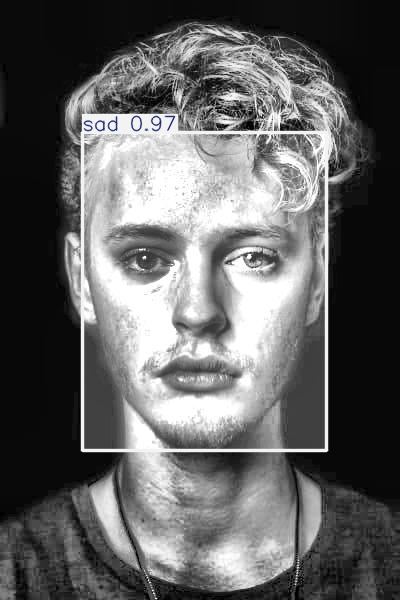

shape: (1, 4)
┌──────┬───────┬────────────┬─────────────────────────────────┐
│ name ┆ class ┆ confidence ┆ box                             │
│ ---  ┆ ---   ┆ ---        ┆ ---                             │
│ str  ┆ i64   ┆ f64        ┆ struct[4]                       │
╞══════╪═══════╪════════════╪═════════════════════════════════╡
│ sad  ┆ 2     ┆ 0.96969    ┆ {82.04103,132.56372,326.27072,… │
└──────┴───────┴────────────┴─────────────────────────────────┘


'results_02e66149-c867-44ae-ace2-c6d0223a667f_JPG.rf.5f14c02f4d155878dd5729e7eedf59fd.jpg'

In [9]:
from ultralytics import YOLO
import cv2

# Load the trained model
model = YOLO('/kaggle/working/Emotion Recobnition/weights/best.pt')  # or your model path

# Predict on a single image
image_path = '/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/train/images/02e66149-c867-44ae-ace2-c6d0223a667f_JPG.rf.5f14c02f4d155878dd5729e7eedf59fd.jpg'  # Update this with the actual image path

# Perform the prediction
results = model.predict(image_path)

# Access the first result in the list (since results is a list of detections)
result = results[0]

# Display the results
result.show()  # To display the image with bounding boxes

# To access the prediction results in detail and convert it to a DataFrame
prediction_df = result.to_df()  # Converts the result to a Polars DataFrame
print(prediction_df)  # Print the predictions (bounding boxes and confidence scores)

# Optional: If you want to save the predictions to an image
result.save()  # Saves the image with bounding boxes in the same directory


image 1/1 /kaggle/input/emotion-recognition-dataset/Facial emotion recognition/train/images/0dbd3d2c-0890-423f-9ae4-29f68d9a7b87_JPG.rf.84211aab4ce5ddcee66ce8e3806abc83.jpg: 640x640 1 sad, 18.0ms
Speed: 2.5ms preprocess, 18.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


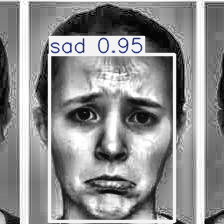

shape: (1, 4)
┌──────┬───────┬────────────┬─────────────────────────────────┐
│ name ┆ class ┆ confidence ┆ box                             │
│ ---  ┆ ---   ┆ ---        ┆ ---                             │
│ str  ┆ i64   ┆ f64        ┆ struct[4]                       │
╞══════╪═══════╪════════════╪═════════════════════════════════╡
│ sad  ┆ 2     ┆ 0.94665    ┆ {49.84479,54.45405,174.69331,2… │
└──────┴───────┴────────────┴─────────────────────────────────┘


'results_0dbd3d2c-0890-423f-9ae4-29f68d9a7b87_JPG.rf.84211aab4ce5ddcee66ce8e3806abc83.jpg'

In [11]:
from ultralytics import YOLO
import cv2

# Load the trained model
model = YOLO('/kaggle/working/Emotion Recobnition/weights/best.pt')  # or your model path

# Predict on a single image
image_path = '/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/train/images/0dbd3d2c-0890-423f-9ae4-29f68d9a7b87_JPG.rf.84211aab4ce5ddcee66ce8e3806abc83.jpg'  # Update this with the actual image path

# Perform the prediction
results = model.predict(image_path)

# Access the first result in the list (since results is a list of detections)
result = results[0]

# Display the results
result.show()  # To display the image with bounding boxes

# To access the prediction results in detail and convert it to a DataFrame
prediction_df = result.to_df()  # Converts the result to a Polars DataFrame
print(prediction_df)  # Print the predictions (bounding boxes and confidence scores)

# Optional: If you want to save the predictions to an image
result.save()  # Saves the image with bounding boxes in the same directory


image 1/1 /kaggle/input/emotion-recognition-dataset/Facial emotion recognition/train/images/1003_jpeg.rf.4aec29134839180f8eba0ddaeb8f7de8.jpg: 480x640 1 happy, 66.0ms
Speed: 1.7ms preprocess, 66.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


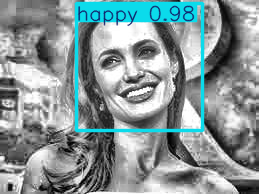

shape: (1, 4)
┌───────┬───────┬────────────┬─────────────────────────────────┐
│ name  ┆ class ┆ confidence ┆ box                             │
│ ---   ┆ ---   ┆ ---        ┆ ---                             │
│ str   ┆ i64   ┆ f64        ┆ struct[4]                       │
╞═══════╪═══════╪════════════╪═════════════════════════════════╡
│ happy ┆ 1     ┆ 0.97599    ┆ {76.65963,3.66681,202.04102,13… │
└───────┴───────┴────────────┴─────────────────────────────────┘


'results_1003_jpeg.rf.4aec29134839180f8eba0ddaeb8f7de8.jpg'

In [ ]:
from ultralytics import YOLO
import cv2

# Load the trained model
model = YOLO('/kaggle/working/Emotion Recobnition/weights/best.pt')  # or your model path

# Predict on a single image
image_path = '/kaggle/input/emotion-recognition-dataset/Facial emotion recognition/train/images/1003_jpeg.rf.4aec29134839180f8eba0ddaeb8f7de8.jpg'  # Update this with the actual image path

# Perform the prediction
results = model.predict(image_path)

# Access the first result in the list (since results is a list of detections)
result = results[0]

# Display the results
result.show()  # To display the image with bounding boxes

# To access the prediction results in detail and convert it to a DataFrame
prediction_df = result.to_df()  # Converts the result to a Polars DataFrame
print(prediction_df)  # Print the predictions (bounding boxes and confidence scores)

# Optional: If you want to save the predictions to an image
result.save()  # Saves the image with bounding boxes in the same directory
#Confidence Score = Accuracy